# Task 5: Personal Loan Acceptance Prediction

### 1. Introduction and Problem Statement
The objective of this project is to predict which customers are most likely to accept a term deposit (personal loan) offer based on the Bank Marketing Dataset. By using classification models, the bank can identify patterns in customer demographics and financial indicators to target the right audience. This reduces telemarketing costs and increases campaign efficiency.

In [1]:

# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# DATASET UNDERSTANDING AND DESCRIPTION
# The dataset uses semicolons ';' as separators.
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Inspect the first 5 rows to understand the features
display(df.head())

# Check the data types and look for any missing values
print(df.info())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### 2. Data Cleaning and Preparation
To prepare our data for machine learning:
1. We must convert the target variable `y` from text ("yes"/"no") into binary numbers (1/0).
2. **Crucial Step:** We must drop the `duration` column. The dataset documentation strictly warns that call duration is only known *after* the call ends. Keeping it in the dataset would cause "data leakage" (cheating by looking at the future).

In [2]:
# Map the target variable to 1s and 0s
df['y_binary'] = df['y'].map({'yes': 1, 'no': 0})

# Drop 'duration' to prevent data leakage, and drop the original 'y' column
X_raw = df.drop(columns=['y', 'y_binary', 'duration'])
y = df['y_binary']

print("Data cleaning complete.")
print(f"Features shape: {X_raw.shape}, Target shape: {y.shape}")

Data cleaning complete.
Features shape: (41188, 19), Target shape: (41188,)


### 3. Exploratory Data Analysis (EDA)
Before training a model, Ivisualized the relationships between customer features (like age, job, and marital status) and their likelihood of accepting the offer.

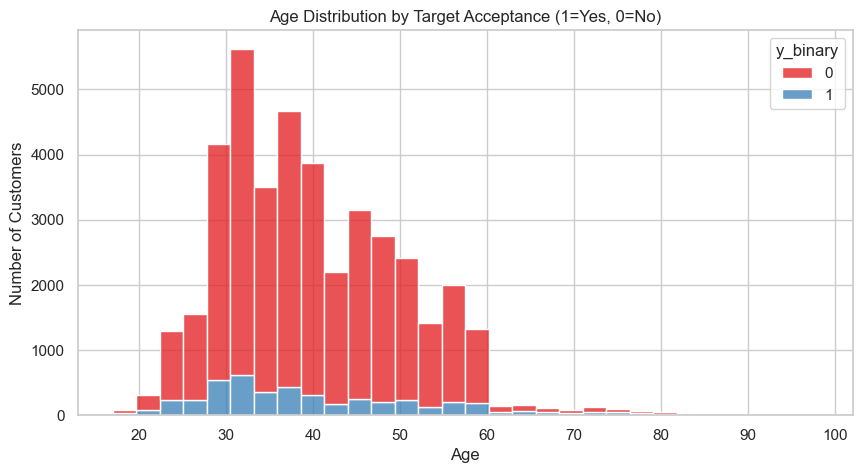

In [3]:
# Set the visual theme for our graphs
sns.set_theme(style="whitegrid")

# Graph 1: Age Distribution vs. Acceptance
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='y_binary', multiple='stack', bins=30, palette='Set1')
plt.title('Age Distribution by Target Acceptance (1=Yes, 0=No)')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

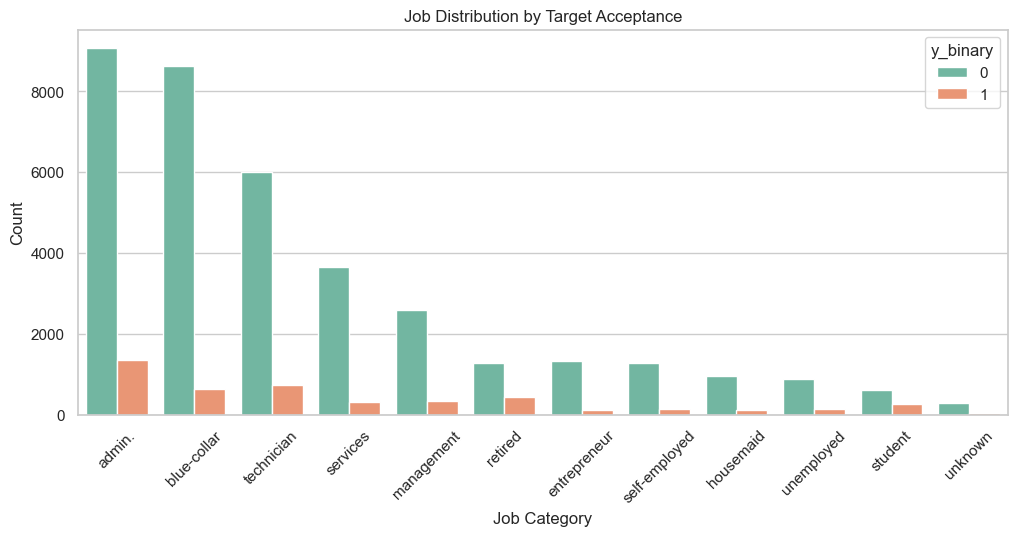

In [4]:
# Graph 2: Job vs. Acceptance
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='job', hue='y_binary', order=df['job'].value_counts().index, palette='Set2')
plt.xticks(rotation=45)
plt.title('Job Distribution by Target Acceptance')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.show()

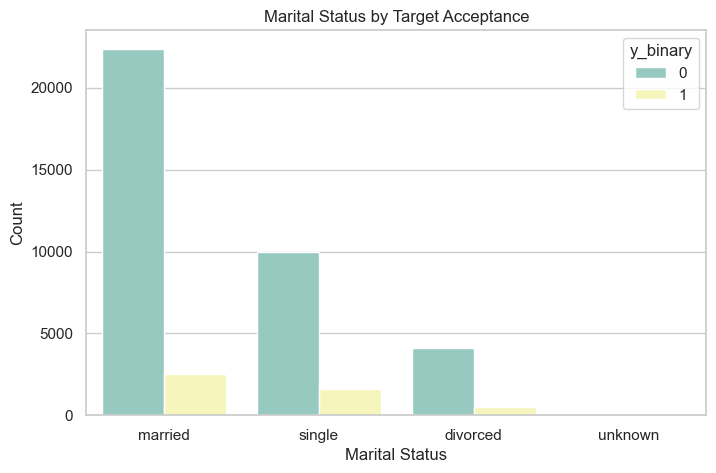

In [5]:
# Graph 3: Marital Status vs. Acceptance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='marital', hue='y_binary', order=df['marital'].value_counts().index, palette='Set3')
plt.title('Marital Status by Target Acceptance')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

### 4. Model Training and Testing
I will use a **Decision Tree Classifier**. 
Because most categories are text (e.g., "married", "technician"), I first used **One-Hot Encoding** (`pd.get_dummies`) to convert them into numbers. I also address "Class Imbalance" (most people say no to loans) by using `class_weight='balanced'` so the model pays equal attention to both "yes" and "no" answers.

In [6]:
# One-hot encode the categorical variables into numerical format
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# Split data into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier
# max_depth=5 prevents the tree from over-memorizing (overfitting) the data
# class_weight='balanced' ensures it treats the rare "Yes" responses fairly
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

# Train the model on the training data
dt_model.fit(X_train, y_train)

# Make predictions using the unseen test data
y_pred = dt_model.predict(X_test)

print("Model training and prediction complete.")

Model training and prediction complete.


### 5. Evaluation Metrics
For classification (Yes/No predictions), I evaluated our model using Accuracy, a Confusion Matrix, and a Classification Report (Precision, Recall, F1-Score). *(Note: MAE and RMSE are used for continuous numbers/regression, not binary classification).*

In [7]:
# 1. Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {acc * 100:.2f}%\n")

Decision Tree Accuracy: 83.95%



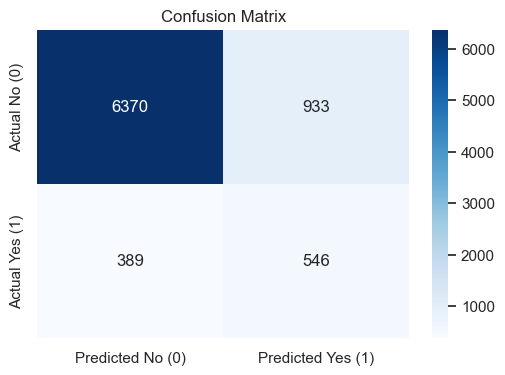

In [8]:
# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'], 
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix')
plt.show()

In [9]:
# 3. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91      7303
           1       0.37      0.58      0.45       935

    accuracy                           0.84      8238
   macro avg       0.66      0.73      0.68      8238
weighted avg       0.88      0.84      0.85      8238



In [10]:
# 4. Feature Importance (Understanding what drove the model's decisions)
importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(5)

print("\nTop 5 Most Important Features for Prediction:")
print(top_features)


Top 5 Most Important Features for Prediction:
nr.employed       0.695895
cons.conf.idx     0.145746
cons.price.idx    0.038464
pdays             0.034747
month_oct         0.024358
dtype: float64


### 6. Conclusion Summarizing Key Insights

**Business Insights Extracted:**
1. **Economic Context is King:** Based on the feature importance from the Decision Tree, `nr.employed` (number of employees/employment rate) and `cons.conf.idx` (consumer confidence index) are the top drivers. People decide to take on loans based on the macroeconomic environment rather than just their personal demographic.
2. **Follow-ups Matter (`pdays`):** The number of days since the client was last contacted heavily influenced the model. Clients engaged in previous campaigns show a higher propensity to accept new offers.
3. **Demographic Targets:** Our EDA reveals that while the bulk volume of calls goes to middle-aged workers (blue-collar, admin), the proportional acceptance rate is highest among "students" and "retirees." 

# **Final Recommendation:**
The bank should align telemarketing efforts with periods of high consumer confidence. Furthermore, they should segment their call lists to prioritize previously contacted individuals, students, and retirees, rather than indiscriminately calling all active working professionals.